# Loan Default Risk Analysis

## Project Overview
Banks face significant financial losses when customers fail to repay loans. 
This project analyses 32,576 real customer records to identify the key factors 
that drive loan default using Python and Power BI.

## Business Questions
1. Which age groups have the highest default rates?
2. Does home ownership affect likelihood of defaulting?
3. Which loan purposes are riskiest?
4. Does income level predict default risk?
5. Does the bank's loan grading system accurately reflect risk?

## Tools Used
- Python (pandas, matplotlib) — data cleaning and analysis
- Power BI — interactive dashboard
- Jupyter Notebook — documented analysis
- GitHub — project sharing

## Dataset
32,576 customer records · 12 columns · Source: Kaggle

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\project\LoanDataset - LoansDatasest.csv')

# First look at the data
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (32586, 13)

First 5 rows:


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [1]:
# Loan Default Risk Analysis
# Phase 1 - Setup & Data Loading

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")
print("Pandas version:", pd.__version__)

Libraries loaded successfully!
Pandas version: 2.3.3


In [3]:
# Explore the dataset
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Column names:
['customer_id', 'customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length', 'Current_loan_status']

Data types:
customer_id            float64
customer_age             int64
customer_income         object
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt               object
loan_int_rate          float64
term_years               int64
historical_default      object
cred_hist_length         int64
Current_loan_status     object
dtype: object

Missing values:
customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default 

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000


In [4]:
# Phase 2 - Data Cleaning

# Step 1: Drop rows where our target column is missing
df = df.dropna(subset=['Current_loan_status'])

# Step 2: Fill missing employment_duration with the median
df['employment_duration'] = df['employment_duration'].fillna(df['employment_duration'].median())

# Step 3: Fill missing loan_int_rate with the median
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Step 4: Fill missing historical_default with 'N' (assume no default)
df['historical_default'] = df['historical_default'].fillna('N')

# Step 5: Remove the bad age row (age over 100 is clearly an error)
df = df[df['customer_age'] <= 100]

# Step 6: Clean the loan_amnt column (remove £ sign and convert to number)
df['loan_amnt'] = df['loan_amnt'].astype(str).str.replace('£','').str.replace(',','').astype(float)

# Check results
print("Cleaned dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Cleaned dataset shape: (32577, 13)

Missing values after cleaning:
customer_id            3
customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              1
loan_int_rate          0
term_years             0
historical_default     0
cred_hist_length       0
Current_loan_status    0
dtype: int64


In [5]:
# Fix the last remaining missing values

# Drop the 1 missing loan amount row
df = df.dropna(subset=['loan_amnt'])

# Drop the customer_id column - we don't need it for analysis
df = df.drop(columns=['customer_id'])

# Confirm everything is clean
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData is clean and ready for analysis!")

Final dataset shape: (32576, 12)

Missing values:
customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              0
loan_int_rate          0
term_years             0
historical_default     0
cred_hist_length       0
Current_loan_status    0
dtype: int64

Data is clean and ready for analysis!


Loan status values:
Current_loan_status
NO DEFAULT    25737
DEFAULT        6839
Name: count, dtype: int64

Default rate:
Current_loan_status
NO DEFAULT    79.01
DEFAULT       20.99
Name: proportion, dtype: float64


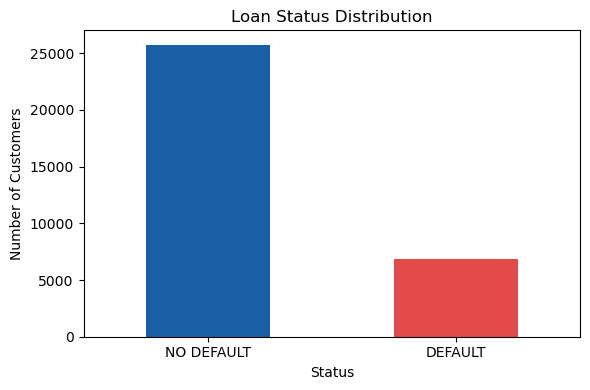

In [6]:
# Phase 3 - Exploratory Data Analysis

# Step 1: Check our target column - loan status
print("Loan status values:")
print(df['Current_loan_status'].value_counts())

print("\nDefault rate:")
default_rate = df['Current_loan_status'].value_counts(normalize=True) * 100
print(default_rate.round(2))

# Visualise it
plt.figure(figsize=(6,4))
df['Current_loan_status'].value_counts().plot(kind='bar', color=['#185FA5','#E24B4A'])
plt.title('Loan Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_5724\4193816953.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('age_group')['Current_loan_status'].apply(


Default rate by age group:
age_group
18-25    22.20
26-35    20.17
36-45    19.00
46-55    17.32
56-65    25.00
65+      16.67
Name: Current_loan_status, dtype: float64


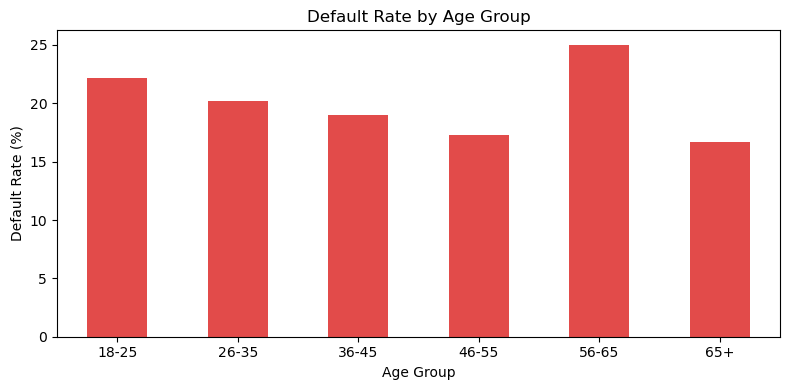

In [7]:
# Step 2: Default rate by age group

# Create age groups
df['age_group'] = pd.cut(df['customer_age'], 
                          bins=[18, 25, 35, 45, 55, 65, 100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])

# Calculate default rate per age group
age_default = df.groupby('age_group')['Current_loan_status'].apply(
    lambda x: (x == 'DEFAULT').sum() / len(x) * 100
).round(2)

print("Default rate by age group:")
print(age_default)

# Chart
plt.figure(figsize=(8,4))
age_default.plot(kind='bar', color='#E24B4A')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Default rate by home ownership:
home_ownership
RENT        30.97
OTHER       30.84
MORTGAGE    11.58
OWN          6.08
Name: Current_loan_status, dtype: float64


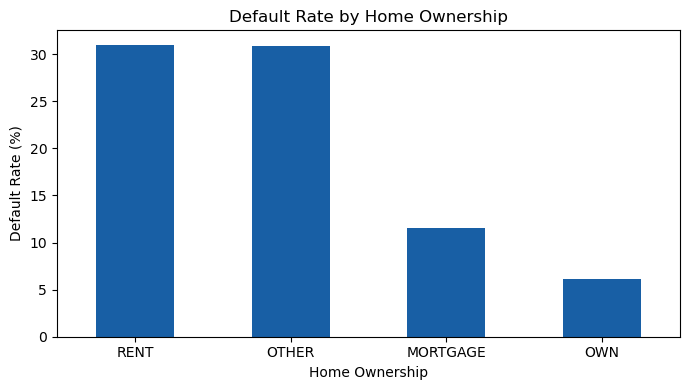

In [8]:
# Step 3: Default rate by home ownership

home_default = df.groupby('home_ownership', observed=True)['Current_loan_status'].apply(
    lambda x: (x == 'DEFAULT').sum() / len(x) * 100
).round(2).sort_values(ascending=False)

print("Default rate by home ownership:")
print(home_default)

# Chart
plt.figure(figsize=(7,4))
home_default.plot(kind='bar', color='#185FA5')
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Default rate by loan intent:
loan_intent
DEBTCONSOLIDATION    30.37
MEDICAL              25.08
HOMEIMPROVEMENT      24.46
PERSONAL             18.53
EDUCATION            15.90
VENTURE              14.03
Name: Current_loan_status, dtype: float64


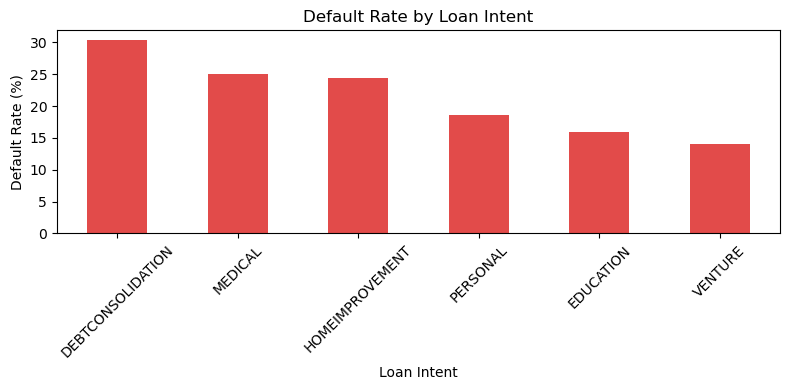

In [9]:
# Step 4: Default rate by loan intent

intent_default = df.groupby('loan_intent', observed=True)['Current_loan_status'].apply(
    lambda x: (x == 'DEFAULT').sum() / len(x) * 100
).round(2).sort_values(ascending=False)

print("Default rate by loan intent:")
print(intent_default)

# Chart
plt.figure(figsize=(8,4))
intent_default.plot(kind='bar', color='#E24B4A')
plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Default rate by income group:
income_group
0-20k     67.66
20-40k    31.43
40-60k    19.67
60-80k    15.25
80k+       8.97
Name: Current_loan_status, dtype: float64


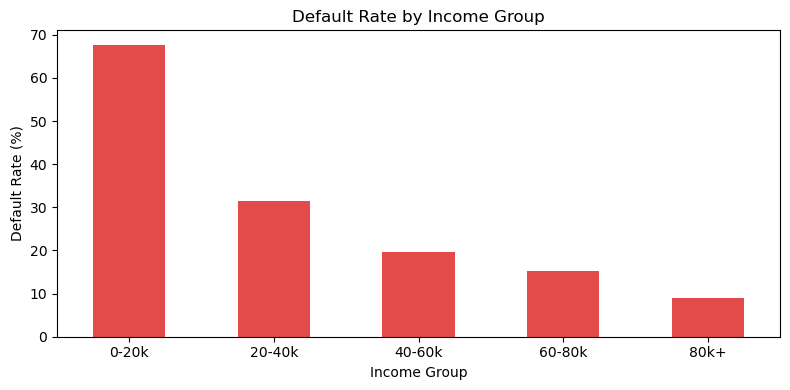

In [10]:
# Step 5: Default rate by income group

# First clean the customer_income column - remove any symbols
df['customer_income'] = df['customer_income'].astype(str).str.replace(',','').astype(float)

# Create income groups
df['income_group'] = pd.cut(df['customer_income'],
                             bins=[0, 20000, 40000, 60000, 80000, 200000],
                             labels=['0-20k','20-40k','40-60k','60-80k','80k+'])

# Calculate default rate per income group
income_default = df.groupby('income_group', observed=True)['Current_loan_status'].apply(
    lambda x: (x == 'DEFAULT').sum() / len(x) * 100
).round(2)

print("Default rate by income group:")
print(income_default)

# Chart
plt.figure(figsize=(8,4))
income_default.plot(kind='bar', color='#E24B4A')
plt.title('Default Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Default rate by loan grade:
loan_grade
A    10.01
B    19.31
C    35.76
D    58.60
E    72.46
Name: Current_loan_status, dtype: float64


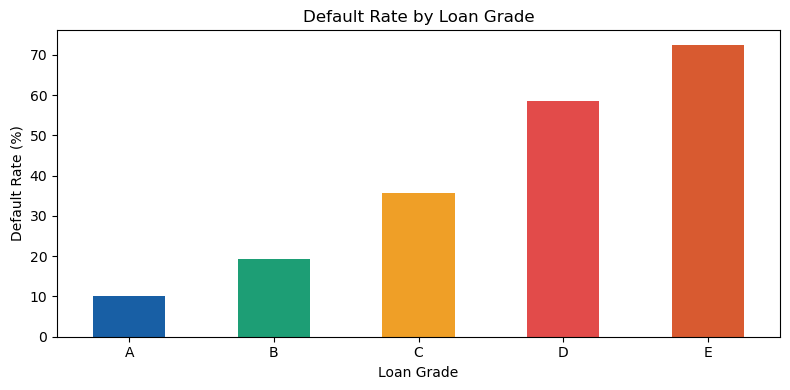

In [11]:
# Step 6: Default rate by loan grade

grade_default = df.groupby('loan_grade', observed=True)['Current_loan_status'].apply(
    lambda x: (x == 'DEFAULT').sum() / len(x) * 100
).round(2).sort_values()

print("Default rate by loan grade:")
print(grade_default)

# Chart
plt.figure(figsize=(8,4))
colors = ['#185FA5','#1D9E75','#EF9F27','#E24B4A','#D85A30','#993C1D','#712B13']
grade_default.plot(kind='bar', color=colors)
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Save the cleaned dataset for Power BI
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print("File location: C:\\Users\\USER\\OneDrive\\Documents\\project\\loan_cleaned.csv")
print("\nPhase 3 Complete! Ready for Power BI dashboard.")

Cleaned dataset saved successfully!
File location: C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv

Phase 3 Complete! Ready for Power BI dashboard.


In [13]:
# Rename loan grades to include the word Grade
df['loan_grade'] = 'Grade ' + df['loan_grade'].astype(str)

# Check it worked
print(df['loan_grade'].value_counts())

# Save the updated file
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)

print("File saved successfully!")

loan_grade
Grade A    15657
Grade B     9062
Grade C     4924
Grade D     2628
Grade E      305
Name: count, dtype: int64
File saved successfully!


In [15]:
# Remove the numbers from income group labels
df['income_group'] = pd.cut(
    df['customer_income'],
    bins=[0, 20000, 40000, 60000, 80000, 999999],
    labels=['0 to 20k', '20k to 40k', '40k to 60k', '60k to 80k', '80k plus']
)

# Check it worked
print(df['income_group'].value_counts())

# Save the updated file
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)

print("\nFile saved successfully!")

income_group
40k to 60k    9445
20k to 40k    8108
80k plus      7640
60k to 80k    6203
0 to 20k      1172
Name: count, dtype: int64

File saved successfully!


In [16]:
# Rename loan intent labels
df['loan_intent'] = df['loan_intent'].replace({
    'DEBTCONSOLIDATION': 'Debt Consolidation',
    'MEDICAL': 'Medical',
    'HOMEIMPROVEMENT': 'Home Improvement',
    'PERSONAL': 'Personal',
    'EDUCATION': 'Education',
    'VENTURE': 'Venture'
})

# Check it worked
print(df['loan_intent'].value_counts())

# Save
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)
print("Saved successfully!")

loan_intent
Education             6451
Medical               6072
Venture               5715
Personal              5520
Debt Consolidation    5212
Home Improvement      3606
Name: count, dtype: int64
Saved successfully!


In [21]:
# Check the problem ages
print("Ages outside our range:")
print(df[df['customer_age'] < 18]['customer_age'].value_counts())

# Remove customers with unrealistic ages (below 18)
df = df[df['customer_age'] >= 18]

# Drop old age_group column
df = df.drop(columns=['age_group'])

# Create fresh clean age groups
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# Verify - should show exactly 6 groups
print("\nAge group counts:")
print(df['age_group'].value_counts().sort_index())
print("\nTotal rows:", len(df))

# Save
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)
print("\nSaved successfully!")

Ages outside our range:
customer_age
6    1
8    1
3    1
Name: count, dtype: int64

Age group counts:
age_group
18-25    15355
26-35    13759
36-45     2811
46-55      514
56-65      104
65+         30
Name: count, dtype: int64

Total rows: 32573

Saved successfully!


In [26]:
# Drop all old age columns
df = df.drop(columns=['age_group', 'age_sort'], errors='ignore')

# Create clean age groups without numbers
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# Save
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)
print("Saved!")

Saved!


In [27]:
# Create age_sort column in Python
age_order = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-55': 4,
    '56-65': 5,
    '65+': 6
}

df['age_sort'] = df['age_group'].map(age_order)

# Verify
print(df[['age_group', 'age_sort']].drop_duplicates().sort_values('age_sort'))

# Save
df.to_csv(r'C:\Users\USER\OneDrive\Documents\project\loan_cleaned.csv', index=False)
print("Saved!")

      age_group age_sort
0         18-25        1
6         26-35        2
29123     36-45        3
29125     46-55        4
32303     56-65        5
32310       65+        6
Saved!
